# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np
import pandas as pd

In [19]:
expressao = np.random.normal(loc=0, scale=1, size=1000)
print(expressao)

[-4.68295921e-02 -1.53628425e-01  1.32883182e+00  1.71389094e-01
 -3.37044975e-01 -1.57501660e+00  1.09959085e-01 -1.20799578e+00
  3.41742233e-01  1.57682620e-01 -1.48501578e+00 -7.04019378e-02
  2.80209577e-01  2.10382374e-01 -1.12887223e+00 -1.92449758e+00
  1.54875167e+00 -1.77985542e-01  4.22057399e-01 -4.30197702e-02
  1.12529592e+00 -1.20240245e+00 -5.27387083e-01 -1.61436035e-01
  5.85780276e-02 -1.15212113e-01  1.93290401e-01 -8.77356216e-01
 -7.14251447e-01 -1.65051172e-02 -1.07576496e+00  5.86098132e-01
  5.33490188e-01  1.56094998e+00  1.11028782e+00  5.94127872e-01
 -9.69325406e-01  1.24220435e+00  1.36053519e+00 -3.18314012e-01
  1.49039174e+00 -3.60931577e-01  1.15685372e+00  1.44570203e+00
 -1.60098245e+00 -1.86574632e+00 -8.88138798e-01  1.18553909e-01
 -1.63624971e+00  1.42188793e+00 -3.54278685e-01  4.46814554e-01
 -1.16672550e+00  5.26684051e-01 -2.97640427e-03 -1.19399323e+00
  7.60361332e-02 -5.39325054e-01  6.18594718e-02  1.00080119e+00
  1.67952160e+00 -2.41208

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [3]:
# número de genes up/down por paciente
genes_up = np.random.randint(100, 500, 1000)
genes_down = np.random.randint(0, 500, 1000)

# criar nomes dos genes
genes = [f'Gene_{i+1}' for i in range(1000)]

# classificar regulação
regulacao = ['Up' if x > 0 else 'Down' for x in expressao]

# criar DataFrame
df_genes = pd.DataFrame({
    'Gene': genes,
    'Expressao': expressao,
    'Regulacao': regulacao
})
# criar pacientes (mesmo tamanho)
pacientes = [f'Paciente_{i+1}' for i in range(1000)]


# adicionar ao DataFrame
df_genes['Paciente'] = pacientes
df_genes['Qtd_genes_Upregulated'] = genes_up
df_genes['Qtd_genes_Downregulated'] = genes_down

print(df_genes)


          Gene  Expressao Regulacao       Paciente  Qtd_genes_Upregulated  \
0       Gene_1  -0.460499      Down     Paciente_1                    455   
1       Gene_2  -0.825726      Down     Paciente_2                    398   
2       Gene_3  -0.571964      Down     Paciente_3                    262   
3       Gene_4   0.712598        Up     Paciente_4                    184   
4       Gene_5   0.571482        Up     Paciente_5                    291   
..         ...        ...       ...            ...                    ...   
995   Gene_996  -0.350212      Down   Paciente_996                    279   
996   Gene_997   0.485814        Up   Paciente_997                    228   
997   Gene_998   1.552299        Up   Paciente_998                    407   
998   Gene_999  -1.183713      Down   Paciente_999                    161   
999  Gene_1000  -1.138287      Down  Paciente_1000                    382   

     Qtd_genes_Downregulated  
0                        170  
1            

## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Os critérios escolhidos foram com base na expressão (até -2 = muito down, de -2 a -1 = down, de -1 a 0 = levemente down, de 0 a 1 = levemente up, de 1 a 2 = up e de 1 a 2 = muito up)

In [4]:
# criterios
bins = [-float('inf'), -2, -1, 0, 1, 2, float('inf')]

labels = [
    'Muito Down',
    'Down',
    'Levemente Down',
    'Levemente Up',
    'Up',
    'Muito Up'
]

df_genes['Grupo_Expressao'] = pd.cut(df_genes['Expressao'], bins=bins, labels=labels)

print(df_genes[['Gene', 'Expressao', 'Grupo_Expressao']])

          Gene  Expressao Grupo_Expressao
0       Gene_1  -0.460499  Levemente Down
1       Gene_2  -0.825726  Levemente Down
2       Gene_3  -0.571964  Levemente Down
3       Gene_4   0.712598    Levemente Up
4       Gene_5   0.571482    Levemente Up
..         ...        ...             ...
995   Gene_996  -0.350212  Levemente Down
996   Gene_997   0.485814    Levemente Up
997   Gene_998   1.552299              Up
998   Gene_999  -1.183713            Down
999  Gene_1000  -1.138287            Down

[1000 rows x 3 columns]


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [5]:
def tabela_frequencia(serie):
    freq_abs = serie.value_counts().sort_index()
    freq_rel = serie.value_counts(normalize=True).sort_index()
    
    df_freq = pd.DataFrame({
        'Frequencia_Absoluta': freq_abs,
        'Frequencia_Relativa': freq_rel
    })
    
    return df_freq

In [6]:
#Exercicio 1
# criar classes (intervalos)
classes = pd.cut(df_genes['Expressao'], bins=6)

tabela_exp = tabela_frequencia(classes)
print(tabela_exp)

                  Frequencia_Absoluta  Frequencia_Relativa
Expressao                                                 
(-3.021, -1.988]                   25                0.025
(-1.988, -0.962]                  150                0.150
(-0.962, 0.0642]                  376                0.376
(0.0642, 1.09]                    317                0.317
(1.09, 2.117]                     116                0.116
(2.117, 3.143]                     16                0.016


In [7]:
#Exercicio 2
tabela_up = tabela_frequencia(df_genes['Qtd_genes_Upregulated'])
tabela_down = tabela_frequencia(df_genes['Qtd_genes_Downregulated'])

print(tabela_up.head())
print(tabela_down.head())

                       Frequencia_Absoluta  Frequencia_Relativa
Qtd_genes_Upregulated                                          
100                                      5                0.005
101                                      2                0.002
102                                      3                0.003
103                                      1                0.001
104                                      2                0.002
                         Frequencia_Absoluta  Frequencia_Relativa
Qtd_genes_Downregulated                                          
1                                          3                0.003
2                                          4                0.004
3                                          4                0.004
5                                          2                0.002
6                                          1                0.001


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

In [8]:
import matplotlib.pyplot as plt

### Expressão

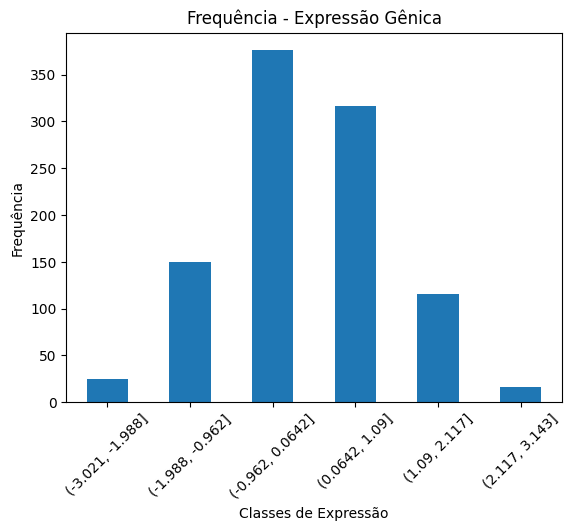

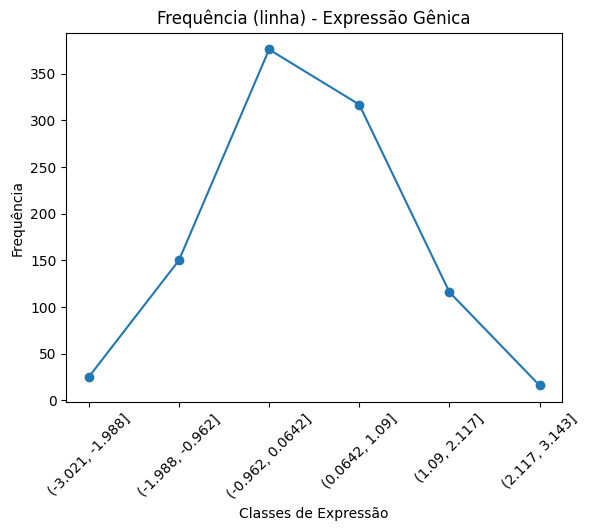

In [9]:
# gráfico de barras
tabela_exp['Frequencia_Absoluta'].plot(kind='bar')
plt.title('Frequência - Expressão Gênica')
plt.xlabel('Classes de Expressão')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.show()

# gráfico de linhas
tabela_exp['Frequencia_Absoluta'].plot(kind='line', marker='o')
plt.title('Frequência (linha) - Expressão Gênica')
plt.xlabel('Classes de Expressão')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.show()

### Número

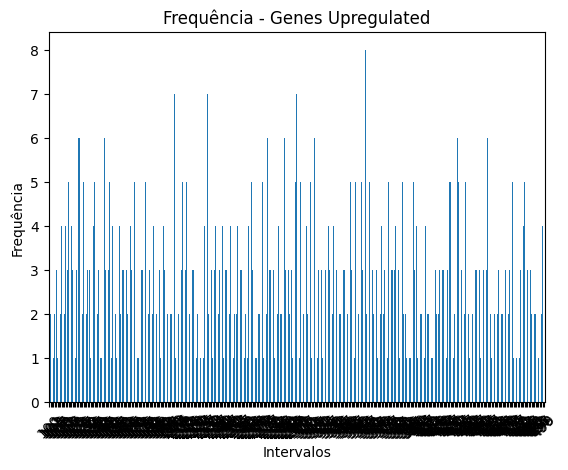

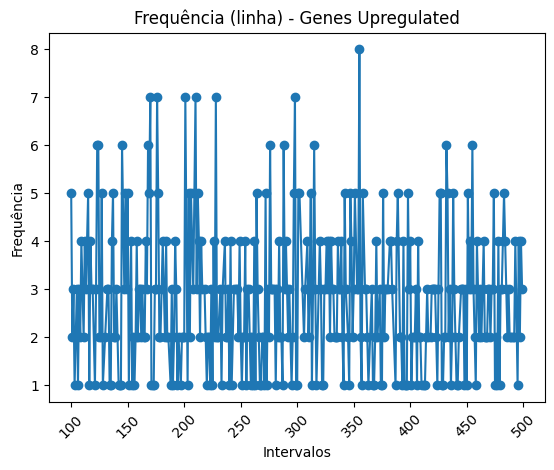

In [10]:
# gráfico de barras
tabela_up['Frequencia_Absoluta'].plot(kind='bar')
plt.title('Frequência - Genes Upregulated')
plt.xlabel('Intervalos')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.show()

# gráfico de linhas
tabela_up['Frequencia_Absoluta'].plot(kind='line', marker='o')
plt.title('Frequência (linha) - Genes Upregulated')
plt.xlabel('Intervalos')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

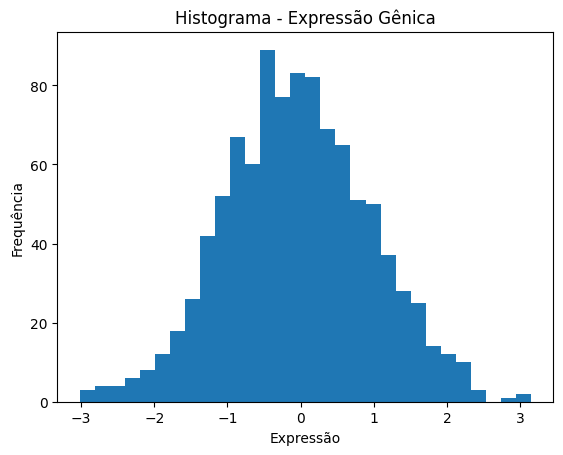

In [11]:
#Exercicio 1
plt.hist(df_genes['Expressao'], bins=30)
plt.title('Histograma - Expressão Gênica')
plt.xlabel('Expressão')
plt.ylabel('Frequência')
plt.show()

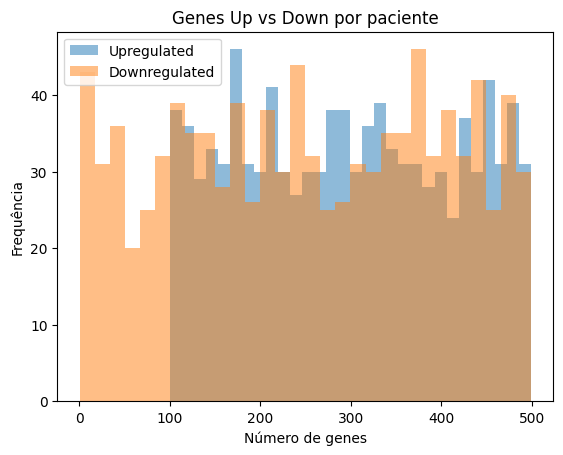

In [12]:
#Exercicio 2
plt.hist(df_genes['Qtd_genes_Upregulated'], bins=30, alpha=0.5, label='Upregulated')
plt.hist(df_genes['Qtd_genes_Downregulated'], bins=30, alpha=0.5, label='Downregulated')

plt.title('Genes Up vs Down por paciente')
plt.xlabel('Número de genes')
plt.ylabel('Frequência')
plt.legend()
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

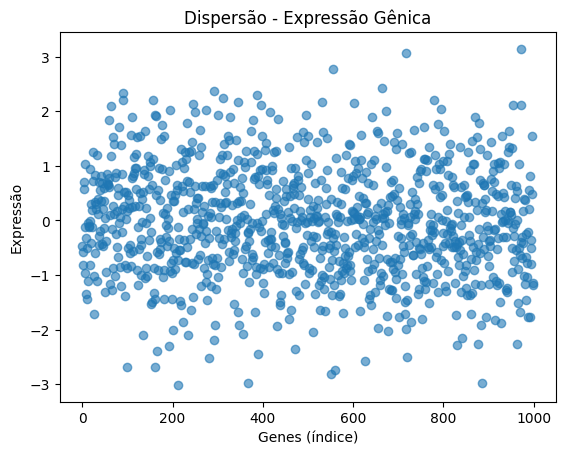

In [13]:
plt.scatter(df_genes.index, df_genes['Expressao'], alpha=0.6)

plt.title('Dispersão - Expressão Gênica')
plt.xlabel('Genes (índice)')
plt.ylabel('Expressão')
plt.show()

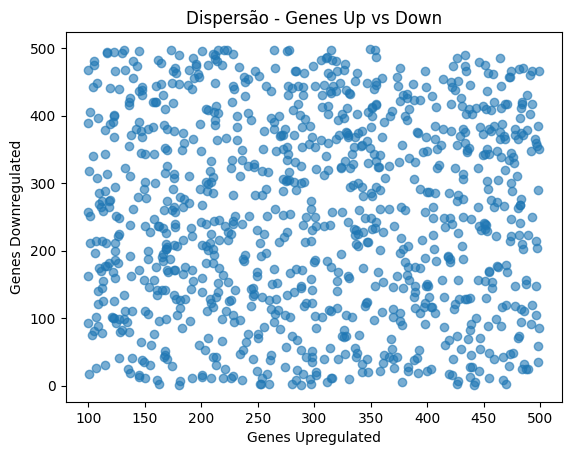

In [14]:
#Exercicio 2
plt.scatter(df_genes['Qtd_genes_Upregulated'], df_genes['Qtd_genes_Downregulated'], alpha=0.6)

plt.title('Dispersão - Genes Up vs Down')
plt.xlabel('Genes Upregulated')
plt.ylabel('Genes Downregulated')
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

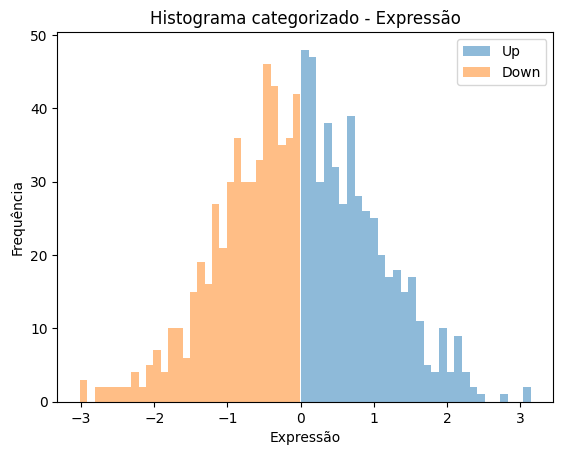

In [15]:
up = df_genes[df_genes['Regulacao'] == 'Up']['Expressao']
down = df_genes[df_genes['Regulacao'] == 'Down']['Expressao']

plt.hist(up, bins=30, alpha=0.5, label='Up')
plt.hist(down, bins=30, alpha=0.5, label='Down')

plt.title('Histograma categorizado - Expressão')
plt.xlabel('Expressão')
plt.ylabel('Frequência')
plt.legend()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

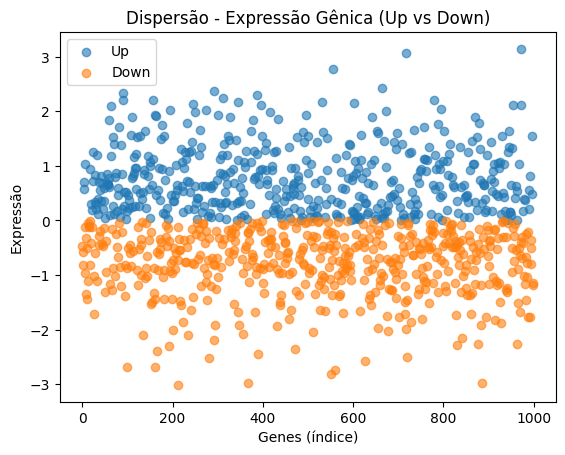

In [16]:
# categorizar
up = df_genes[df_genes['Regulacao'] == 'Up']
down = df_genes[df_genes['Regulacao'] == 'Down']

# gráfico
plt.scatter(up.index, up['Expressao'], label='Up', alpha=0.6)
plt.scatter(down.index, down['Expressao'], label='Down', alpha=0.6)

plt.title('Dispersão - Expressão Gênica (Up vs Down)')
plt.xlabel('Genes (índice)')
plt.ylabel('Expressão')
plt.legend()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas| discreta |
| % de células positivas| contínua |
| Faixa de pH| ordinal |
| Valor de pH| contínua |
| mol/L| contínua |
| UFC| discreta |
| D.O.| contínua |
| Grupo Sanguíneo| nominal |
| Sorologia| nominal |